# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [2]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
df = pd.read_csv(PROCESSED_DIR / "SPY.csv")
df['volume'] = df['volume'].replace(0, np.nan)
df.head()
# - parse 'date' as datetime index, sort ascending

# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN



,Unnamed: 0,date,adj_close,close,high,low,open,volume,symbol
0,0,2015-01-02,170.125000,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,1,2015-01-05,167.052612,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2,2015-01-06,165.479141,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,3,2015-01-07,167.541183,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,4,2015-01-08,170.514267,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [3]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [4]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.
#
return_1     = close.pct_change(1)
return_5     = close.pct_change(5)
log_return_1 = np.log(close / close.shift(1))

df['return_1'] = return_1
df['return_5'] = return_5
df['log_return_1'] = log_return_1

df['date'].dtype


dtype('O')

## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [5]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df['sma_20']      = close.rolling(20).mean()
df['sma_50']      = close.rolling(50).mean()
df['sma_200']     = close.rolling(500).mean()
df['sma_ratio_20'] =(close/df['sma_20'])-1
df['sma_ratio_50'] =(close/df['sma_50'])-1

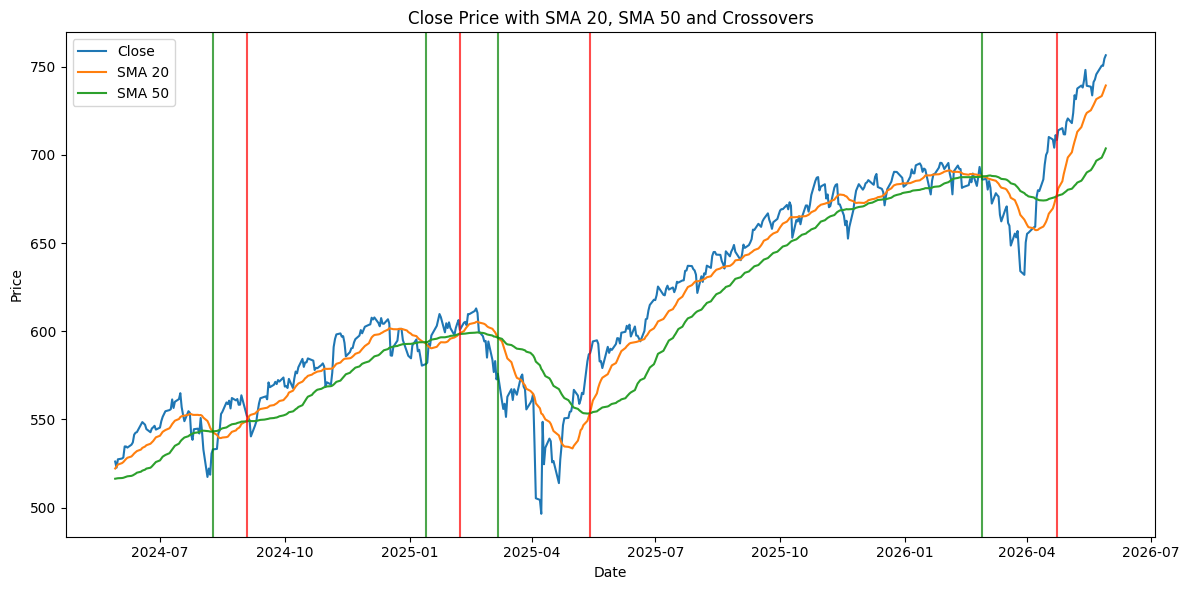

In [6]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

#Force the date column to become datetime objects
df['date'] = pd.to_datetime(df['date'])

end_date = df['date'].max()
start_date = end_date - pd.DateOffset(years=2)

df['diff'] = df['sma_50'] - df['sma_20']


recent = df[df['date'] >= start_date]  #its a dataframe
cross  = np.sign(recent['diff'])
golden_mask=cross > cross.shift(1) #its a series with index and boolean values
golden = recent[golden_mask]
death_mask = cross < cross.shift(1)
death  = recent[ death_mask]

# Plot Graph
plt.figure(figsize=(12, 6))

plt.title('Close Price with SMA 20, SMA 50 and Crossovers')

plt.plot(recent['date'], recent['close'], label='Close')
plt.plot(recent['date'], recent['sma_20'], label='SMA 20')
plt.plot(recent['date'], recent['sma_50'], label='SMA 50')

for date in golden['date']:
    plt.axvline(x=date, color='green', alpha=0.7)

for date in death['date']:
    plt.axvline(x=date, color='red', alpha=0.7)

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.tight_layout()

plt.show()



## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [7]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20

df['ema_12']       = df['close'].ewm(span=12).mean()
df['ema_20']       = df['close'].ewm(span=20).mean()
df['ema_26']       = df['close'].ewm(span=26).mean()
df['ema_ratio_20'] = (close/df['ema_20'])-1

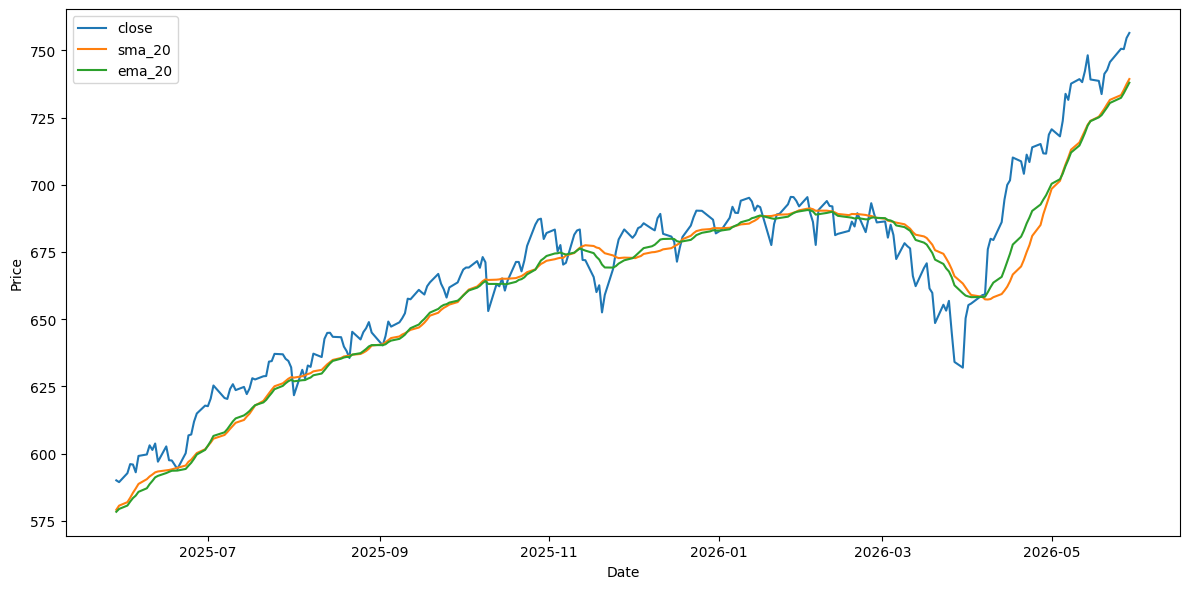

In [8]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA

end_date=df['date'].max()
start_date=end_date-pd.DateOffset(years=1)
recent=df[df['date']>= start_date]

plt.figure(figsize=(12,6))
plt.plot(recent['date'], recent['close'], label='close')
plt.plot(recent['date'],recent['sma_20'],label='sma_20')
plt.plot(recent['date'],recent['ema_20'],label='ema_20')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()

plt.tight_layout()

plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [9]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)
n=14
delta    = df['close']-df['close'].shift(1)
gain     = delta.clip(lower=0)
loss     = delta.clip(upper=0)*-1
avg_gain = gain.ewm(com=n-1, adjust=False).mean()
avg_loss = loss.ewm(com=n-1, adjust=False).mean()
rs       = avg_gain/avg_loss
df['rsi_14'] = (100-(100/(1+rs)))/100

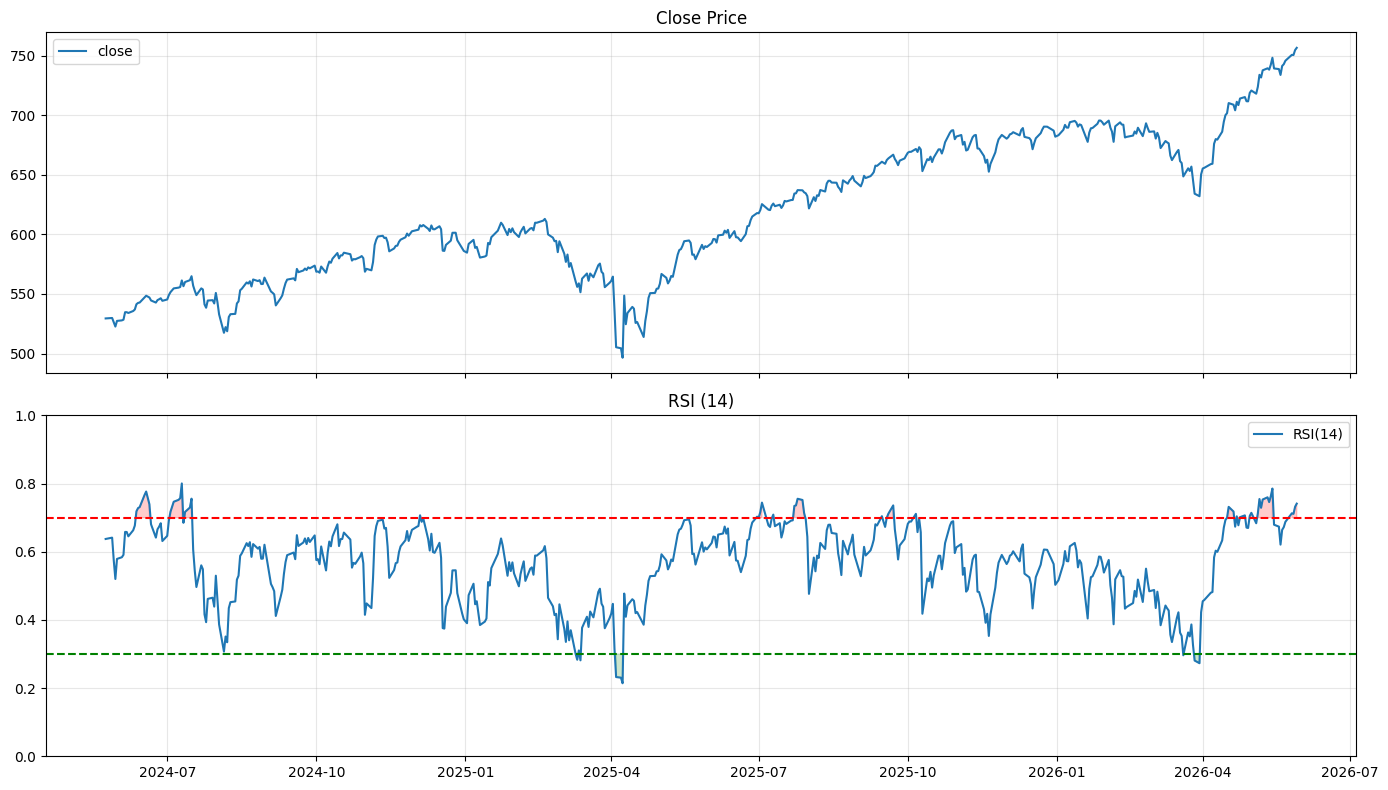

In [10]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green

# Last 2 years
recent = df.tail(504)

# Create two panels
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True
)

ax1.plot(recent['date'],recent['close'],label='close')
ax1.set_title('Close Price')
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2.plot(recent['date'], recent['rsi_14'], label='RSI(14)')

# Overbought / Oversold levels
ax2.axhline(0.70, color='red', linestyle='--')
ax2.axhline(0.30, color='green', linestyle='--')

# Shade overbought region
ax2.fill_between(
    recent['date'],
    recent['rsi_14'],
    0.70,
    where=recent['rsi_14'] > 0.70,
    alpha=0.2,
    color='red'
)

# Shade oversold region
ax2.fill_between(
    recent['date'],
    recent['rsi_14'],
    0.30,
    where=recent['rsi_14'] < 0.30,
    alpha=0.2,
    color='green'
)



ax2.set_title('RSI (14)')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [11]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

# MACD line
df['macd'] = df['ema_12'] - df['ema_26']

# Signal line (9-period EMA of MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# Histogram
df['macd_hist'] = df['macd'] - df['macd_signal']

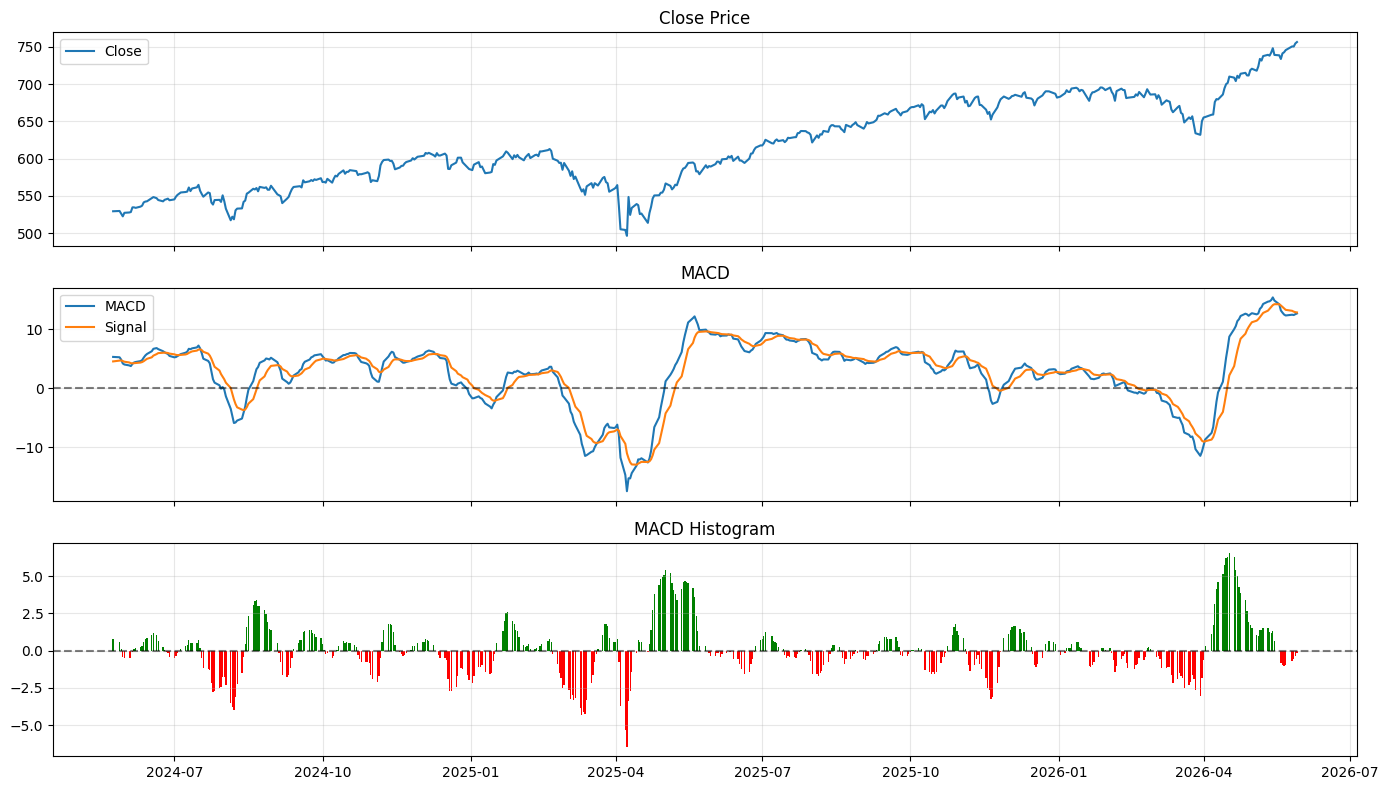

In [12]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign

recent=df.tail(504)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(14, 8),
    sharex=True
)

# ------------------
# Price
# ------------------
ax1.plot(recent['date'], recent['close'], label='Close')
ax1.set_title('Close Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ------------------
# MACD + Signal
# ------------------
ax2.plot(recent['date'], recent['macd'], label='MACD')
ax2.plot(recent['date'], recent['macd_signal'], label='Signal')

ax2.axhline(0, color='black', linestyle='--', alpha=0.5)

ax2.set_title('MACD')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ------------------
# Histogram
# ------------------
colors = ['green' if x >= 0 else 'red'
          for x in recent['macd_hist']]

ax3.bar(
    recent['date'],
    recent['macd_hist'],
    color=colors
)

ax3.axhline(0, color='black', linestyle='--', alpha=0.5)

ax3.set_title('MACD Histogram')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [13]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std = df['close'].rolling(window=20).std()

df['bb_upper'] = df['sma_20'] + 2 * rolling_std
df['bb_lower'] = df['sma_20'] - 2 * rolling_std

df['bb_width'] = (
    df['bb_upper'] - df['bb_lower']
) / df['close']

df['bb_pct_b'] = (
    (df['close'] - df['bb_lower']) /
    (df['bb_upper'] - df['bb_lower'])
).clip(0, 1)  # clip to [0, 1] optional but useful

## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [14]:
# TODO 6 — Compute roc_5 and roc_10

df['roc_5'] = df['close'].pct_change(periods=5)
df['roc_10'] = df['close'].pct_change(periods=10)

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [15]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)
prev_close = df['close'].shift(1)

true_range = pd.concat([
    df['high'] - df['low'],
    abs(df['high'] - prev_close),
    abs(df['low'] - prev_close)
], axis=1).max(axis=1)

df['atr_14'] = true_range.ewm(com=13, adjust=False).mean()

df['atr_ratio'] = df['atr_14'] / df['close']

## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [16]:
# TODO 8.1 — Compute stoch_k and stoch_d

lowest_low   = df['low'].rolling(window=14).min()
highest_high = df['high'].rolling(window=14).max()
df['stoch_k'] = (
    (df['close'] - lowest_low)
    /
    (highest_high - lowest_low)
)

df['stoch_d'] = df['stoch_k'].rolling(window=3).mean()

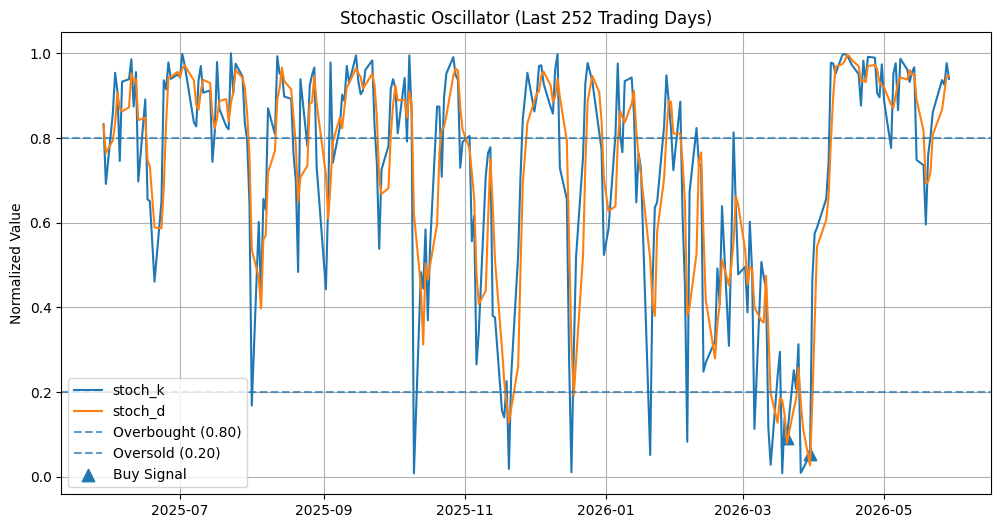

In [17]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# Mark buy signals (%K crosses above %D below 0.20)

recent = df.tail(252)

buy_signal = (
    (recent['stoch_k'].shift(1) <= recent['stoch_d'].shift(1))
    &
    (recent['stoch_k'] > recent['stoch_d'])
    &
    (recent['stoch_k'] < 0.20)
)

plt.figure(figsize=(12, 6))

plt.plot(
    recent['date'],
    recent['stoch_k'],
    label='stoch_k'
)

plt.plot(
    recent['date'],
    recent['stoch_d'],
    label='stoch_d'
)

plt.axhline(
    y=0.80,
    linestyle='--',
    alpha=0.7,
    label='Overbought (0.80)'
)

plt.axhline(
    y=0.20,
    linestyle='--',
    alpha=0.7,
    label='Oversold (0.20)'
)

plt.scatter(
    recent.loc[buy_signal, 'date'],
    recent.loc[buy_signal, 'stoch_k'],
    marker='^',
    s=80,
    label='Buy Signal'
)

plt.title('Stochastic Oscillator (Last 252 Trading Days)')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True)

plt.show()

## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [18]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction = np.sign(close.diff())

df['obv'] = (direction * df['volume']).cumsum()

df['obv_change'] = df['obv'].pct_change()

## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [19]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price = (df['high'] + df['low'] + df['close']) / 3

tp_vol = typical_price * df['volume']

df['vwap'] = (
    tp_vol.rolling(window=20).sum()
    /
    df['volume'].rolling(window=20).sum()
)

df['vwap_ratio'] = df['close'] / df['vwap'] - 1

## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [20]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio',
]

In [22]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

df['future_return'] = df['close'].shift(-1) / df['close'] - 1
df['target_direction'] = np.sign(df['future_return']).clip(lower=0)

required = FEATURE_COLUMNS + ['target_direction']
df       = df.replace([np.inf, -np.inf], np.nan)
df_clean = df[required].dropna()

df_clean.to_csv("data/processed/SPY_features.csv", index=False)

print(f"Saved {len(df_clean)} rows to SPY_features.csv")

# df_clean[required].describe().round(4)
len(df)

Saved 2818 rows to SPY_features.csv


2868

In [23]:
def create_features(df):

    close = df['close']

    # ---- Returns ----
    df['return_1'] = close.pct_change(1)
    df['return_5'] = close.pct_change(5)
    df['log_return_1'] = np.log(close / close.shift(1))

    # ---- SMA ----
    df['sma_20'] = close.rolling(20).mean()
    df['sma_50'] = close.rolling(50).mean()

    df['sma_ratio_20'] = (close / df['sma_20']) - 1
    df['sma_ratio_50'] = (close / df['sma_50']) - 1

    # ---- EMA ----
    df['ema_12'] = close.ewm(span=12).mean()
    df['ema_20'] = close.ewm(span=20).mean()
    df['ema_26'] = close.ewm(span=26).mean()

    df['ema_ratio_20'] = (close / df['ema_20']) - 1

    # ---- RSI ----
    n = 14

    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)

    avg_gain = gain.ewm(com=n-1, adjust=False).mean()
    avg_loss = loss.ewm(com=n-1, adjust=False).mean()

    rs = avg_gain / avg_loss

    df['rsi_14'] = (100 - (100 / (1 + rs))) / 100

    # ---- MACD ----
    df['macd'] = df['ema_12'] - df['ema_26']
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

    # ---- ROC ----
    df['roc_5'] = close.pct_change(5)
    df['roc_10'] = close.pct_change(10)

    # ---- Bollinger ----
    rolling_std = close.rolling(20).std()

    bb_upper = df['sma_20'] + 2 * rolling_std
    bb_lower = df['sma_20'] - 2 * rolling_std

    df['bb_width'] = (bb_upper - bb_lower) / close

    df['bb_pct_b'] = (
        (close - bb_lower)
        /
        (bb_upper - bb_lower)
    ).clip(0, 1)

    # ---- ATR ----
    prev_close = close.shift(1)

    true_range = pd.concat([
        df['high'] - df['low'],
        (df['high'] - prev_close).abs(),
        (df['low'] - prev_close).abs()
    ], axis=1).max(axis=1)

    df['atr_14'] = true_range.ewm(
        com=13,
        adjust=False
    ).mean()

    df['atr_ratio'] = df['atr_14'] / close

    # ---- Stochastic ----
    lowest_low = df['low'].rolling(14).min()
    highest_high = df['high'].rolling(14).max()

    df['stoch_k'] = (
        (close - lowest_low)
        /
        (highest_high - lowest_low)
    )

    df['stoch_d'] = (
        df['stoch_k']
        .rolling(3)
        .mean()
    )

    # ---- OBV ----
    direction = np.sign(close.diff())

    df['obv'] = (
        direction * df['volume']
    ).cumsum()

    df['obv_change'] = df['obv'].pct_change()

    # ---- VWAP ----
    typical_price = (
        df['high']
        + df['low']
        + close
    ) / 3

    tp_vol = typical_price * df['volume']

    df['vwap'] = (
        tp_vol.rolling(20).sum()
        /
        df['volume'].rolling(20).sum()
    )

    df['vwap_ratio'] = close / df['vwap'] - 1

    return df

In [25]:
# TODO 11.2 (Challenge) — Run the full pipeline for ALL downloaded symbols
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

summary = []
for csv_path in RAW_DIR.glob("*.csv"):
    sym = csv_path.stem
    try:
        raw       = pd.read_csv(csv_path)
        processed=create_features(raw)
        processed.to_csv(f"data/processed/{sym}_features.csv", index=False)
        # ... save to PROCESSED_DIR ...
        # summary.append({...})
    except Exception as e:
        summary.append({'symbol': sym, 'error': str(e)})



---
